## Airbnb Chatbot
Collaborators: Ben Ghouzi, Shawn Lokshin, Khadiatou Ly, Veronica Song

Goal: Build a chatbot that can process user's natural language queries to recommend experiences and services based on user-user filtering and selected housing location

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd

listings = pd.read_csv("listings.csv")
reviews = pd.read_csv("reviews.csv")
user_booking = pd.read_csv("user_bookings.csv")

user_booking.head()

,user_id,listing_id,city,trip_purpose,guests,nights_stayed,total_paid,rating,booking_month
0,U0145,L0290,Chicago,group,4,3,834,5,10
1,U0189,L0337,New York,leisure,2,3,768,4,7
2,U0172,L0016,Boston,leisure,2,7,1197,3,3
3,U0020,L0465,Miami,romantic,2,7,826,5,2
4,U0024,L0148,Boston,leisure,1,5,550,5,12


# User-user Collaborative Filtering

In [29]:
# -------------------------------
# USER-USER COLLABORATIVE FILTERING
# -------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Build matrix
ratings_df = user_booking[["user_id", "listing_id", "rating"]]

user_item = ratings_df.pivot_table(
    index="user_id",
    columns="listing_id",
    values="rating",
    aggfunc="mean"
)

global_mean = ratings_df["rating"].mean()
user_means = user_item.mean(axis=1)
item_means = user_item.mean(axis=0)
item_support = user_item.notna().sum(axis=0)

# Normalize for similarity
user_item_centered = user_item.sub(user_means, axis=0)
user_item_filled = user_item_centered.fillna(0)

# Similarity
user_sim = pd.DataFrame(
    cosine_similarity(user_item_filled),
    index=user_item.index,
    columns=user_item.index
)

# Overlap
overlap_matrix = user_item.notna().astype(int).dot(user_item.notna().astype(int).T)

# Shrink item mean
def get_shrunk_item_mean(lid, alpha=10):
    if lid not in item_means.index:
        return global_mean
    m = item_means[lid]
    n = item_support[lid]
    if pd.isna(m):
        return global_mean
    return (n*m + alpha*global_mean)/(n+alpha)

# Prediction
def predict_user_user(user, item, k=10):
    if user not in user_item.index or item not in user_item.columns:
        val = get_shrunk_item_mean(item)
        return val, val, 0, 0

    if not pd.isna(user_item.loc[user, item]):
        val = user_item.loc[user, item]
        return val, val, 999, 1

    user_mean = user_means[user] if not pd.isna(user_means[user]) else global_mean

    neighbors = []
    for other in user_item.index:
        if other == user: continue
        if pd.isna(user_item.loc[other, item]): continue

        sim = user_sim.loc[user, other]
        overlap = overlap_matrix.loc[user, other]

        if sim > 0 and overlap >= 1:
            neighbors.append((other, sim))

    if not neighbors:
        val = get_shrunk_item_mean(item)
        return val, val, 0, 0

    neighbors = sorted(neighbors, key=lambda x: x[1], reverse=True)[:k]

    num, den = 0, 0
    for n, sim in neighbors:
        r = user_item.loc[n, item]
        m = user_means[n] if not pd.isna(user_means[n]) else global_mean
        num += sim * (r - m)
        den += abs(sim)

    adj = num/den if den else 0
    raw = user_mean + adj
    pred = float(np.clip(raw, 1, 5))

    return pred, raw, len(neighbors), min(1, den)

# Full scoring
def get_all_scores(user):
    seen = set(user_item.loc[user].dropna().index)

    rows = []
    for lid in user_item.columns:
        if lid in seen: continue

        pred, raw, support, conf = predict_user_user(user, lid)

        rank = 0.7*raw + 0.2*conf + 0.1*np.log1p(item_support.get(lid,0))

        rows.append({
            "listing_id": lid,
            "predicted": pred,
            "raw": raw,
            "support": support,
            "confidence": conf,
            "rank": rank
        })

    df = pd.DataFrame(rows).sort_values("rank", ascending=False)
    return df.reset_index(drop=True)

# Spectrum split
def get_spectrum(user, n=10):
    df = get_all_scores(user)

    top = df.head(n)
    bottom = df.tail(n).sort_values("rank")
    mid_start = len(df)//2 - n//2
    middle = df.iloc[mid_start:mid_start+n]

    return top, middle, bottom

In [ ]:
# Full recommendation table (best to worst)

sample_user = user_booking["user_id"].iloc[0]

df = get_all_scores(sample_user)

print(df.head(20))   # top 20 recommendations

   listing_id  predicted       raw  support  confidence      rank
0       L0533   5.000000  5.380952        1    0.566947  4.128547
1       L0150   5.000000  5.555556        1    0.121716  4.107823
2       L0064   5.000000  5.555556        1    0.121716  4.107823
3       L0034   5.000000  5.555556        1    0.121716  4.051862
4       L0600   5.000000  5.380952        1    0.566947  4.041000
5       L0404   5.000000  5.380952        1    0.566947  4.018685
6       L0329   5.000000  5.354167        1    0.069525  3.956413
7       L0353   5.000000  5.354167        1    0.069525  3.940998
8       L0389   5.000000  5.354167        1    0.069525  3.922765
9       L0249   5.000000  5.354167        1    0.069525  3.900451
10      L0088   5.000000  5.354167        1    0.069525  3.871683
11      L0481   4.854167  4.854167        1    0.069525  3.606413
12      L0362   4.625617  4.625617        0    0.000000  3.457655
13      L0423   4.555556  4.555556        1    0.121716  3.443491
14      L0

In [ ]:
# Top / middle / bottom tables with listing details

top, middle, bottom = get_spectrum(sample_user, n=5)

display(top.merge(listings, on="listing_id"))
display(middle.merge(listings, on="listing_id"))
display(bottom.merge(listings, on="listing_id"))

,listing_id,predicted,raw,support,confidence,rank,city,neighborhood,property_type,bedrooms,...,price_per_night,amenities,host_rating,superhost,instant_book,min_nights,nearest_transit,transit_walk_min,nearby_attraction_1,nearby_attraction_2
0,L0533,5.0,5.380952,1,0.566947,4.128547,Chicago,Hyde Park,Entire home,1,...,163,WiFi; Free parking; Carbon monoxide alarm; Pat...,4.58,0,1,2,Addison L,8,Millennium Park,Wrigley Field
1,L0150,5.0,5.555556,1,0.121716,4.107823,Boston,Jamaica Plain,Private room,1,...,90,Hair dryer; Kitchen; Pool; Workspace; BBQ gril...,4.51,0,1,5,Charles/MGH,22,Harvard Yard,Museum of Fine Arts
2,L0064,5.0,5.555556,1,0.121716,4.107823,Miami,Edgewater,Entire home,5,...,297,Workspace; Gym access; Patio; Pet friendly; TV...,4.84,1,1,3,Coconut Grove Metrorail,22,Art Deco Historic District,Jungle Island
3,L0034,5.0,5.555556,1,0.121716,4.051862,Miami,Midtown,Entire home,1,...,216,Fire extinguisher; Hot tub; BBQ grill; WiFi; P...,4.17,0,1,5,Dadeland South Metrorail,24,Everglades Day Trip,Little Havana Walk
4,L0600,5.0,5.380952,1,0.566947,4.041000,Chicago,Wicker Park,Private room,1,...,176,WiFi; Gym access; Hot tub; Washer; Crib,4.91,0,1,2,Chicago L (Red),9,Art Institute of Chicago,Millennium Park


,listing_id,predicted,raw,support,confidence,rank,city,neighborhood,property_type,bedrooms,...,price_per_night,amenities,host_rating,superhost,instant_book,min_nights,nearest_transit,transit_walk_min,nearby_attraction_1,nearby_attraction_2
0,L0173,4.355093,4.355093,0,0.0,3.158426,Boston,Charlestown,Entire home,1,...,185,Hair dryer; Washer; Hot tub; Kitchen; Workspac...,4.33,0,1,2,Kenmore,13,Harvard Yard,Boston Public Garden
1,L0207,4.355093,4.355093,0,0.0,3.158426,Boston,Fenway-Kenmore,Entire home,1,...,204,Workspace; Carbon monoxide alarm; Smoke alarm;...,4.52,0,1,2,Haymarket,16,Harvard Yard,Fenway Park
2,L0217,4.355093,4.355093,0,0.0,3.158426,Miami,Midtown,Entire home,3,...,254,Heating; Gym access; Hair dryer; Dishwasher; C...,4.85,0,1,1,Dadeland South Metrorail,12,Vizcaya Museum,South Beach
3,L0411,4.355093,4.355093,0,0.0,3.158426,Boston,Cambridge,Entire home,2,...,194,Pool; Kitchen; Workspace; Hot tub; Carbon mono...,4.56,0,1,2,Park Street,9,Faneuil Hall,Newbury Street
4,L0445,4.355093,4.355093,0,0.0,3.158426,San Francisco,North Beach,Private room,1,...,130,Dryer; Gym access; BBQ grill; Pet friendly; Ir...,4.19,0,1,3,Van Ness Muni,18,Golden Gate Park,Chinatown


,listing_id,predicted,raw,support,confidence,rank,city,neighborhood,property_type,bedrooms,...,price_per_night,amenities,host_rating,superhost,instant_book,min_nights,nearest_transit,transit_walk_min,nearby_attraction_1,nearby_attraction_2
0,L0406,1.354167,1.354167,1,0.069525,1.140998,San Francisco,Pacific Heights,Entire home,2,...,270,Crib; Smoke alarm; Washer; Workspace; Patio; C...,4.88,1,1,7,Castro Muni,8,Pier 39,Golden Gate Bridge
1,L0474,2.555556,2.555556,1,0.121716,1.923093,Chicago,Loop,Entire home,3,...,279,WiFi; Gym access; Kitchen; Dishwasher; Heating...,4.62,0,1,3,Western L (Blue),7,Art Institute of Chicago,Lincoln Park Zoo
2,L0241,3.555556,3.555556,1,0.121716,2.707823,San Francisco,Nob Hill,Shared room,1,...,114,Iron; Workspace; Coffee maker; Pet friendly; D...,4.91,0,0,3,Embarcadero BART,12,Fisherman's Wharf,Ferry Building
3,L0561,4.023737,4.023737,0,0.000000,2.885931,New York,East Village,Entire home,5,...,344,Hot tub; WiFi; EV charger; Carbon monoxide ala...,4.62,0,1,1,Atlantic Ave-Barclays,15,Rockefeller Center,Empire State Building
4,L0557,4.021759,4.021759,0,0.000000,2.925093,Boston,Jamaica Plain,Entire home,4,...,244,Pet friendly; Fire extinguisher; Coffee maker;...,4.89,1,1,2,North Station,5,MIT Campus,Boston Common


In [ ]:
# Similarity table

target_user = sample_user

sim_df = user_sim.loc[target_user].sort_values(ascending=False)

print(sim_df.head(10))

user_id
U0145    1.000000
U0112    0.566947
U0160    0.121716
U0227    0.069525
U0003    0.000000
U0006    0.000000
U0007    0.000000
U0004    0.000000
U0005    0.000000
U0001    0.000000
Name: U0145, dtype: float64


LLM prompt used: Act like a professional data scientist. I have csv files called user_bookings.csv and listings.csv. The user_bookings.csv file contains user booking and rating history, including user_id, listing_id, and rating. Please build a user-user collaborative filtering model in Python using cosine similarity to identify similar users, predict listing preference scores for unseen listings, and rank recommendations for a target user.

In [32]:
import matplotlib.pyplot as plt

def plot_spectrum(user, n=8):
    top, middle, bottom = get_spectrum(user, n)

    # make safe copies
    top = top.copy()
    middle = middle.copy()
    bottom = bottom.copy()

    print("Top rows:", len(top))
    print("Middle rows:", len(middle))
    print("Bottom rows:", len(bottom))

    if top.empty and middle.empty and bottom.empty:
        print("No data to plot.")
        return

    top["group"] = "Top"
    middle["group"] = "Middle"
    bottom["group"] = "Least"

    df = pd.concat([bottom, middle, top], ignore_index=True)

    if df.empty:
        print("Combined dataframe is empty.")
        return

    print(df[["listing_id", "rank", "group"]].head())

    df["label"] = df["listing_id"].astype(str)

    plt.figure(figsize=(10, 8))
    plt.barh(df["label"], df["rank"])

    plt.title(f"Recommendation Spectrum for {user}")
    plt.xlabel("Score")
    plt.ylabel("Listings")

    n_bottom = len(bottom)
    n_middle = len(middle)

    if n_bottom > 0:
        plt.axhline(n_bottom - 0.5)
    if n_middle > 0:
        plt.axhline(n_bottom + n_middle - 0.5)

    plt.tight_layout()
    plt.show()

Top rows: 8
Middle rows: 8
Bottom rows: 8
  listing_id      rank  group
0      L0406  1.140998  Least
1      L0474  1.923093  Least
2      L0241  2.707823  Least
3      L0561  2.885931  Least
4      L0557  2.925093  Least


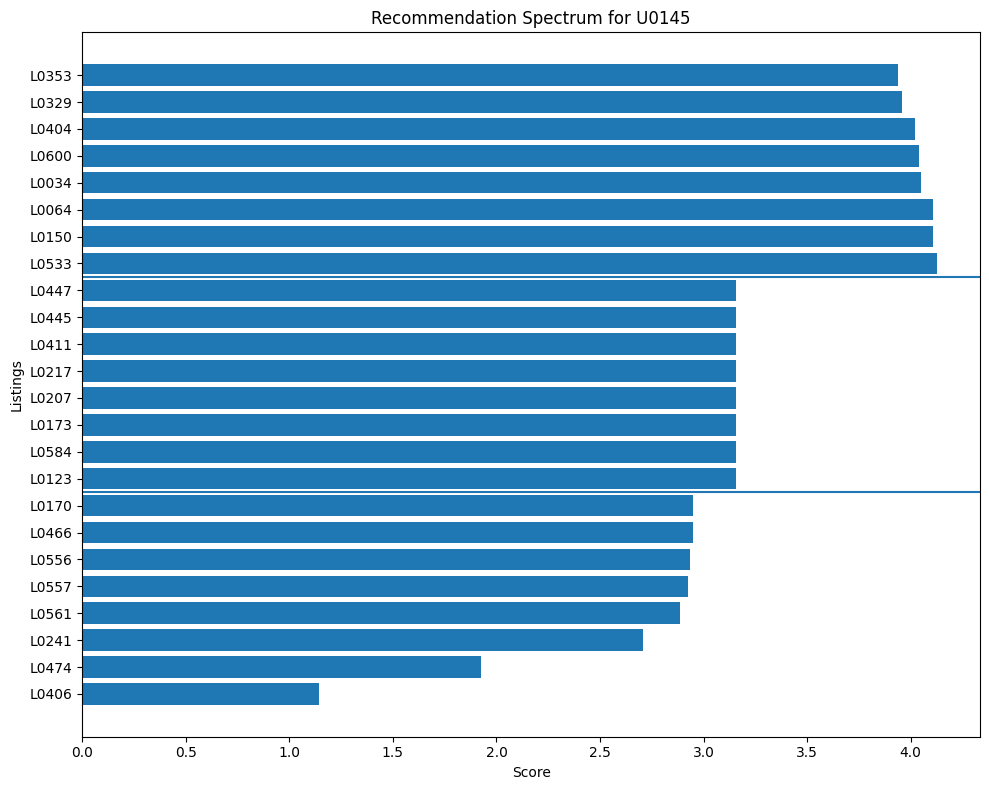

In [33]:
sample_user = user_booking["user_id"].iloc[0]
plot_spectrum(sample_user)

LLM prompt used: Act like a professional data scientist. I have already built a user-user collaborative filtering model in Python that produces ranked recommendation scores for Airbnb listings by user. Please create a Python visualization that shows the top recommended, middle-ranked, and least recommended listings for a sample user in a clear horizontal bar chart for presentation purposes.

In [34]:
import matplotlib.pyplot as plt

def plot_user_similarity_heatmap(target_user, top_n=10):
    if target_user not in user_sim.index:
        print("User not found.")
        return

    # get top similar users including target user
    sims = user_sim.loc[target_user].sort_values(ascending=False).head(top_n + 1)
    selected_users = sims.index.tolist()

    heatmap_df = user_sim.loc[selected_users, selected_users]

    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap_df, aspect='auto')
    plt.colorbar(label="Similarity")

    plt.xticks(range(len(selected_users)), selected_users, rotation=45)
    plt.yticks(range(len(selected_users)), selected_users)

    plt.title(f"User Similarity Heatmap Around {target_user}")
    plt.tight_layout()
    plt.show()

In [35]:
import matplotlib.pyplot as plt

def plot_user_similarity_heatmap(target_user, top_n=10):
    if target_user not in user_sim.index:
        print("User not found.")
        return

    # get top similar users including target user
    sims = user_sim.loc[target_user].sort_values(ascending=False).head(top_n + 1)
    selected_users = sims.index.tolist()

    heatmap_df = user_sim.loc[selected_users, selected_users]

    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap_df, aspect='auto')
    plt.colorbar(label="Similarity")

    plt.xticks(range(len(selected_users)), selected_users, rotation=45)
    plt.yticks(range(len(selected_users)), selected_users)

    plt.title(f"User Similarity Heatmap Around {target_user}")
    plt.tight_layout()
    plt.show()

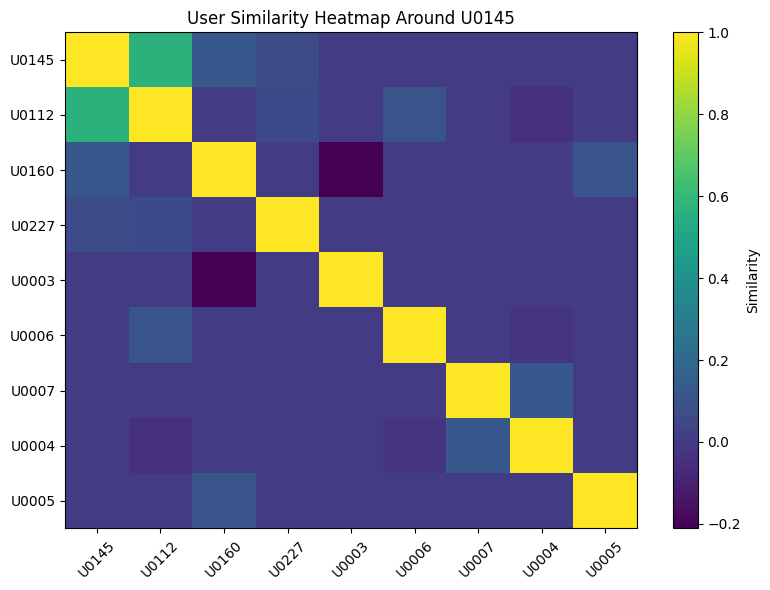

In [36]:
sample_user = user_booking["user_id"].iloc[0]
plot_user_similarity_heatmap(sample_user, top_n=8)

LLM prompt used: Act like a professional data scientist. I have already computed a user-user cosine similarity matrix for an Airbnb recommendation model in Python. Please create a Python heatmap visualization showing the target user and their most similar neighboring users so that I can clearly explain how collaborative filtering is using similarity to generate recommendations.